In [11]:
import pandas as pd

splits = {'train': 'train.csv', 'validation': 'valid.csv', 'test': 'test.csv'}
df = pd.read_csv("hf://datasets/papluca/language-identification/" + splits["train"])

## EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   labels  70000 non-null  object
 1   text    70000 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
df.head(50)

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro."
1,bg,размерът на хоризонталната мрежа може да бъде по реда на няколко километра ( km ) за на симулация до около 100 km за на симулация .
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把这段话复制走了，既能赚积分，还省事，走到哪复制到哪，最重要的是，不用认真的评论了，不用想还差多少字，直接发出就可以了，推荐给大家！！
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ของเก่า ที่ ไม่ 29 สำหรับ เฟอร์นิเจอร์ และ เงิน ไท ร้อง บริษัท ที่ 122 สำหรับ ลาย คราม
4,ru,Он увеличил давление .
5,pl,"S Jak sobie życzysz: Widzisz, jak Hitler zabija Żydów?"
6,ur,اس کے بارے میں ، سفید شادی کی شرح کے بعد سفید اورنمایاں طور پر سفید اورنمایاں طور پر .
7,sw,"Zabuni ya ushindani pia imekuwa rahisi kwa sifa ya kurudi kwenye mapendekezo yake ya grant , na dudovitz hivi karibuni ilikuwa kulea kwa ajili ya kuendeleza nyenzo za matangazo ya slick na kushiriki fedha kwa mipango nyingine ya mapendeleo ya umma kwa juhudi za shirikishi za afya , utetezi wa sera , homelessness , nyumbani msaada wa vurugu , msaada wa kibinafsi na maendeleo ya teknolojia ."
8,tr,"Devasa 12 yüzyıl abbatiale saint-Pierre-Et-Saint-Paul , Aziz Peter ' ın 17 yüzyılda Roma ' da tamamlama kadar Hıristiyan ' en büyük kilisesi idi ."
9,ur,موجودہ اثاثوں میں سے ایک کا اضافہ ہو سکتا ہے ۔


In [ ]:
x = df['labels'].value_counts().index
y = df['labels'].value_counts().values

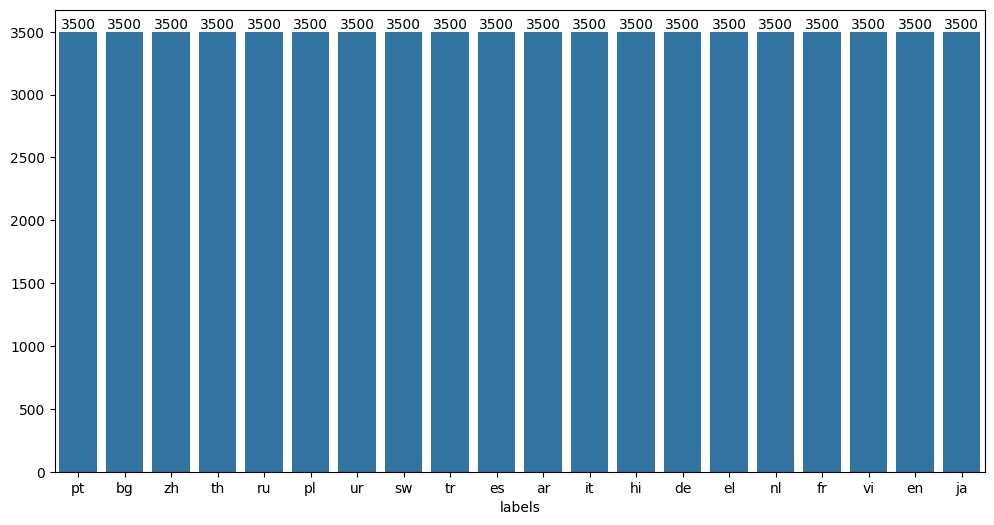

In [ ]:
import seaborn as sns

ax = sns.barplot(x=x, y=y, estimator="sum", errorbar=None)
ax.figure.set_size_inches(12, 6)
ax.bar_label(ax.containers[0], fontsize=10);

## Preprocessing

- Cleaning and Preprocessing are:
    - 1 Remove Punctation
    - 2 Remove Emojis
    - 3 Remove Numbers
    - 4 Remove Extra Spaces
    - 5 Lower Case the words

In [2]:
import numpy as np
import re
from sklearn.base import BaseEstimator, TransformerMixin
import string
import unicodedata

class RemovingPunctation(BaseEstimator, TransformerMixin):
    def __init__(self):
      pass

    def fit(self, X, y=None):
      return self

    def transform(self, X):
      res = X.copy()
      if not isinstance(res,np.ndarray):
        res = res.to_numpy()

      res = np.array([
          ''.join(
              ' ' if unicodedata.category(ch).startswith('P') else ch
              for ch in str(text)
          )
          for text in res
      ])
      return res

In [3]:
import regex

class RemovingEmojis(BaseEstimator, TransformerMixin):
    def __init__(self):
      pass

    def fit(self, X, y=None):
      return self

    def transform(self, X):
      res = X.copy()
      if not isinstance(res,np.ndarray):
        res = res.to_numpy()

      res = np.array([regex.sub(r'\p{Emoji}', '', str(x)) for x in res])
      return res

In [4]:
class RemovingNumbers(BaseEstimator, TransformerMixin):
    def __init__(self):
      pass

    def fit(self, X, y=None):
      return self

    def transform(self, X):
      res = X.copy()
      if not isinstance(res,np.ndarray):
        res = res.to_numpy()

      res = np.array([re.sub(r'\d', ' ', str(x)) for x in res])
      return res

In [5]:
class ShrinkSpaces(BaseEstimator, TransformerMixin):
    def __init__(self):
      pass

    def fit(self, X, y=None):
      return self

    def transform(self, X):
      res = X.copy()
      if not isinstance(res,np.ndarray):
        res = res.to_numpy()

      res = np.array([re.sub(r'\s+', ' ', str(x)) for x in res])
      return res

In [6]:
from sklearn.preprocessing import FunctionTransformer

def to_lower(X):
    return np.array([str(x).lower() for x in X], dtype=object)

LT = FunctionTransformer(to_lower)

In [47]:
from sklearn.pipeline import  make_pipeline

CleaningPipe = make_pipeline(RemovingPunctation(), RemovingEmojis(), RemovingNumbers(), ShrinkSpaces(), LT)

In [8]:
temb = df.iloc[:50]['text']

In [ ]:
res = CleaningPipe.transform(temb)

In [ ]:
pd.DataFrame(res)

,0
0,os chefes de defesa da estónia letónia lituânia alemanha itália espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro
1,размерът на хоризонталната мрежа може да бъде по реда на няколко километра km за на симулация до около km за на симулация
2,很好 以前从不去评价 不知道浪费了多少积分 现在知道积分可以换钱 就要好好评价了 后来我就把这段话复制走了 既能赚积分 还省事 走到哪复制到哪 最重要的是 不用认真的评论了 不用想还差多少字 直接发出就可以了 推荐给大家
3,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ของเก่า ที่ ไม่ สำหรับ เฟอร์นิเจอร์ และ เงิน ไท ร้อง บริษัท ที่ สำหรับ ลาย คราม
4,он увеличил давление
5,s jak sobie życzysz widzisz jak hitler zabija żydów
6,اس کے بارے میں سفید شادی کی شرح کے بعد سفید اورنمایاں طور پر سفید اورنمایاں طور پر
7,zabuni ya ushindani pia imekuwa rahisi kwa sifa ya kurudi kwenye mapendekezo yake ya grant na dudovitz hivi karibuni ilikuwa kulea kwa ajili ya kuendeleza nyenzo za matangazo ya slick na kushiriki fedha kwa mipango nyingine ya mapendeleo ya umma kwa juhudi za shirikishi za afya utetezi wa sera homelessness nyumbani msaada wa vurugu msaada wa kibinafsi na maendeleo ya teknolojia
8,devasa yüzyıl abbatiale saint pierre et saint paul aziz peter ın yüzyılda roma da tamamlama kadar hıristiyan en büyük kilisesi idi
9,موجودہ اثاثوں میں سے ایک کا اضافہ ہو سکتا ہے


In [9]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()
df['labels'] = LE.fit_transform(df['labels'])

## Modeling

### Modeling function

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score,StratifiedKFold
import catboost as cb
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline

def GetScores(preprocessing,Vectorizer,X,Y):
  models = [
    LogisticRegression(),
    SVC(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    xgb.XGBClassifier(),
    cb.CatBoostClassifier(verbose=1, task_type="GPU", devices="0"),
    AdaBoostClassifier(),
    ]
  model_names = [
    "Logistic Regression",
    "(SVC)",
    "DT",
    "RF",
    "XGBoost",
    "CatBoost",
    "AdaBoost",
  ]

  SCV = StratifiedKFold(n_splits=3)
  Results = {}
  for model,name in zip(models,model_names):
    print(name)

    pipeline = Pipeline(steps=[('preprocessing', preprocessing),
                              ('Vectorizing', Vectorizer),
                              ('model', model),])
    ModelRes = cross_val_score(pipeline, X, Y, scoring = 'f1_macro', cv=SCV).mean()
    Results[name] = ModelRes

  return Results

### CountVectroizer

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

res = GetScores(CleaningPipe, CountVectorizer(), df['text'], df['labels'])

Logistic Regression
(SVC)
DT
RF
XGBoost
CatBoost
Learning rate set to 0.142154
0:	learn: 2.6547732	total: 568ms	remaining: 9m 27s
1:	learn: 2.3830330	total: 921ms	remaining: 7m 39s
2:	learn: 2.2036334	total: 1.32s	remaining: 7m 20s
3:	learn: 2.1279373	total: 1.69s	remaining: 7m 1s
4:	learn: 2.0659765	total: 2.09s	remaining: 6m 56s
5:	learn: 2.0108253	total: 2.44s	remaining: 6m 44s
6:	learn: 1.9454268	total: 2.93s	remaining: 6m 55s
7:	learn: 1.9064244	total: 3.32s	remaining: 6m 51s
8:	learn: 1.8523830	total: 3.81s	remaining: 6m 59s
9:	learn: 1.8191781	total: 4.17s	remaining: 6m 52s
10:	learn: 1.7866909	total: 4.55s	remaining: 6m 48s
11:	learn: 1.7578234	total: 4.9s	remaining: 6m 43s
12:	learn: 1.7276445	total: 5.25s	remaining: 6m 38s
13:	learn: 1.6994294	total: 5.67s	remaining: 6m 39s
14:	learn: 1.6765296	total: 6.04s	remaining: 6m 36s
15:	learn: 1.6457160	total: 6.5s	remaining: 6m 39s
16:	learn: 1.6244939	total: 6.89s	remaining: 6m 38s
17:	learn: 1.6031616	total: 7.26s	remaining: 6m 36

[Text(0, 0, '0.928668'),
 Text(0, 0, '0.876521'),
 Text(0, 0, '0.857185'),
 Text(0, 0, '0.875423'),
 Text(0, 0, '0.905593'),
 Text(0, 0, '0.872913'),
 Text(0, 0, '0.48624')]

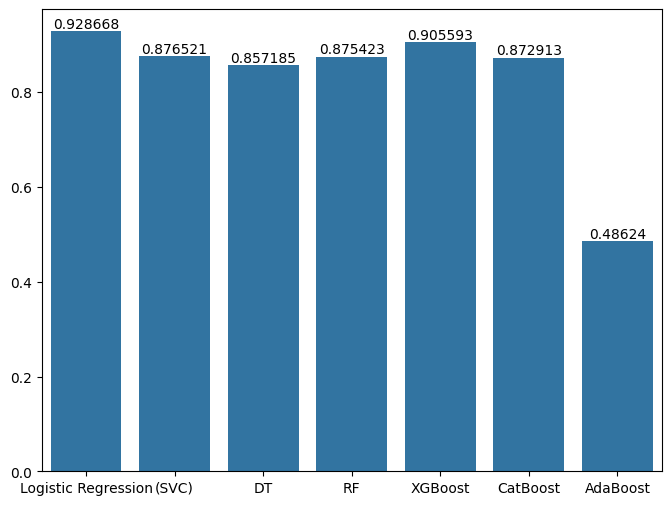

In [ ]:

ax = sns.barplot(x=res.keys(), y=res.values())
ax.figure.set_size_inches(8, 6)
ax.bar_label(ax.containers[0])

### Binary Count Vectroizer

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

res = GetScores(CleaningPipe, CountVectorizer(binary = True), df['text'], df['labels'])

Logistic Regression
(SVC)
DT
RF
XGBoost
CatBoost
Learning rate set to 0.142154
0:	learn: 2.6547741	total: 673ms	remaining: 11m 12s
1:	learn: 2.3826930	total: 925ms	remaining: 7m 41s
2:	learn: 2.2035501	total: 1.2s	remaining: 6m 39s
3:	learn: 2.1252866	total: 1.46s	remaining: 6m 2s
4:	learn: 2.0686169	total: 1.69s	remaining: 5m 36s
5:	learn: 2.0098936	total: 1.99s	remaining: 5m 28s
6:	learn: 1.9483264	total: 2.26s	remaining: 5m 20s
7:	learn: 1.9073581	total: 2.5s	remaining: 5m 9s
8:	learn: 1.8531802	total: 2.84s	remaining: 5m 13s
9:	learn: 1.8181256	total: 3.08s	remaining: 5m 5s
10:	learn: 1.7873534	total: 3.31s	remaining: 4m 57s
11:	learn: 1.7590169	total: 3.55s	remaining: 4m 52s
12:	learn: 1.7262573	total: 3.79s	remaining: 4m 47s
13:	learn: 1.6992087	total: 4.01s	remaining: 4m 42s
14:	learn: 1.6699020	total: 4.25s	remaining: 4m 39s
15:	learn: 1.6463453	total: 4.48s	remaining: 4m 35s
16:	learn: 1.6238197	total: 4.72s	remaining: 4m 33s
17:	learn: 1.5902020	total: 5.09s	remaining: 4m 37s

[Text(0, 0, '0.92892'),
 Text(0, 0, '0.894024'),
 Text(0, 0, '0.855793'),
 Text(0, 0, '0.874542'),
 Text(0, 0, '0.906096'),
 Text(0, 0, '0.875009'),
 Text(0, 0, '0.48624')]

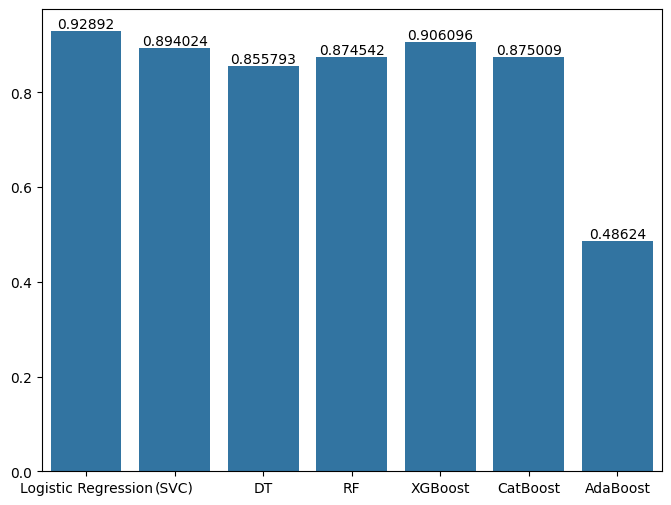

In [14]:
ax = sns.barplot(x=res.keys(), y=res.values())
ax.figure.set_size_inches(8, 6)
ax.bar_label(ax.containers[0])

### tf_idf

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

res = GetScores(CleaningPipe, TfidfVectorizer(), df['text'], df['labels'])

Logistic Regression
(SVC)
DT
RF
XGBoost
CatBoost
Learning rate set to 0.142154
0:	learn: 2.6547607	total: 1.02s	remaining: 17m
1:	learn: 2.3830132	total: 1.74s	remaining: 14m 25s
2:	learn: 2.2035864	total: 2.56s	remaining: 14m 10s
3:	learn: 2.1278983	total: 3.3s	remaining: 13m 42s
4:	learn: 2.0660828	total: 4.18s	remaining: 13m 52s
5:	learn: 2.0093899	total: 4.94s	remaining: 13m 38s
6:	learn: 1.9657876	total: 5.66s	remaining: 13m 22s
7:	learn: 1.9051707	total: 6.69s	remaining: 13m 49s
8:	learn: 1.8522106	total: 7.52s	remaining: 13m 47s
9:	learn: 1.8179287	total: 8.26s	remaining: 13m 37s
10:	learn: 1.7836716	total: 9.08s	remaining: 13m 36s
11:	learn: 1.7553987	total: 9.79s	remaining: 13m 26s
12:	learn: 1.7293591	total: 10.5s	remaining: 13m 18s
13:	learn: 1.6953301	total: 11.3s	remaining: 13m 17s
14:	learn: 1.6676150	total: 12.1s	remaining: 13m 14s
15:	learn: 1.6448482	total: 12.9s	remaining: 13m 12s
16:	learn: 1.6222059	total: 13.6s	remaining: 13m 8s
17:	learn: 1.5979134	total: 14.4s	re

[Text(0, 0, '0.927803'),
 Text(0, 0, '0.886361'),
 Text(0, 0, '0.85228'),
 Text(0, 0, '0.875219'),
 Text(0, 0, '0.896962'),
 Text(0, 0, '0.884273'),
 Text(0, 0, '0.487514')]

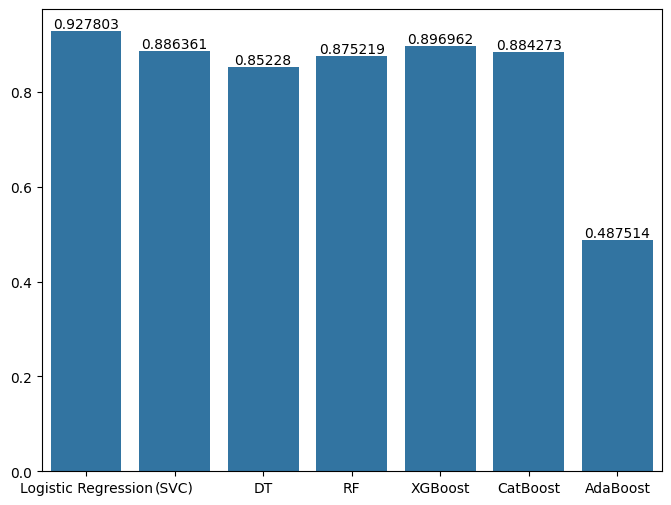

In [ ]:
ax = sns.barplot(x=res.keys(), y=res.values())
ax.figure.set_size_inches(8, 6)
ax.bar_label(ax.containers[0])

In [12]:
df_train = pd.read_csv("hf://datasets/papluca/language-identification/" + splits["train"])
df_val = pd.read_csv("hf://datasets/papluca/language-identification/" + splits["validation"])
df_test = pd.read_csv("hf://datasets/papluca/language-identification/" + splits["test"])

In [28]:
X_full = pd.concat([df_train['text'], df_val['text']], axis=0)
y_full = np.concat([LE.transform(df_train['labels']), LE.transform(df_val['labels'])], axis=0)

In [52]:
full_pipeline = Pipeline([
    ('Preprocessing', CleaningPipe),
    ('Vectroizer', CountVectorizer(binary = True)),
    ('clf', LogisticRegression())
])

In [ ]:
from sklearn.model_selection import cross_val_predict, cross_val_score

y_pred = cross_val_predict(full_pipeline, X_full, y_full, cv=5, verbose = 1)

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  2.4min finished


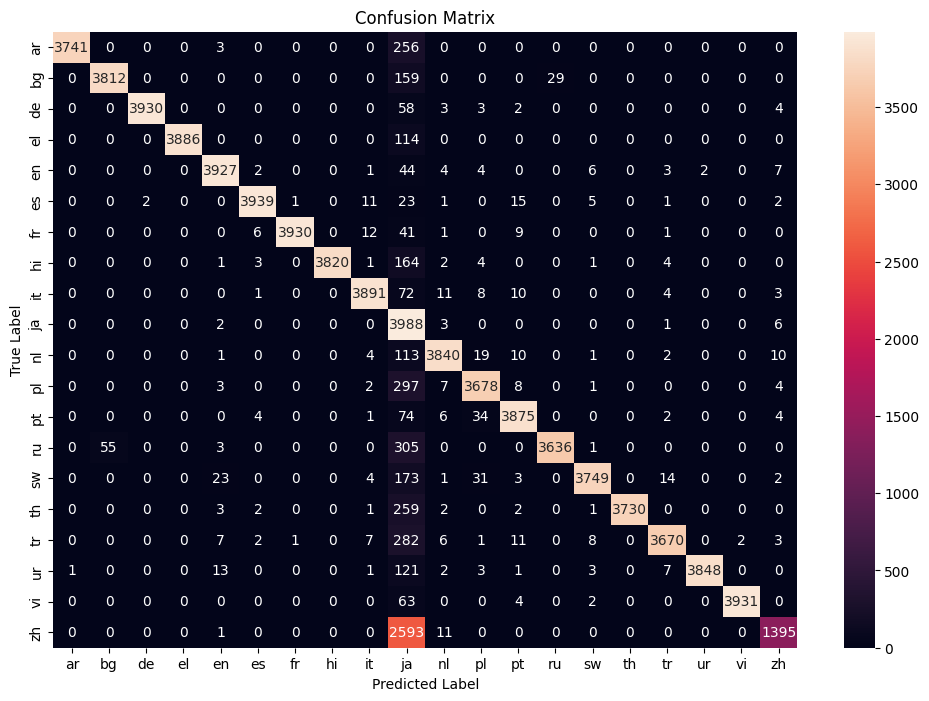

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

labels = LE.classes_ 

cm = confusion_matrix(y_full, y_pred)

plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [40]:
print(cross_val_score(full_pipeline, X_full, y_full, cv=5, scoring= 'f1_macro'))

[0.9354432  0.93201052 0.93423499 0.93130281 0.92760949]


In [53]:
full_pipeline.fit(X_full,y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Preprocessing', ...), ('Vectroizer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('removingpunctation', ...), ('removingemojis', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function to_...001B0F754B1A0>
,"inverse_func inverse_func: callable, default=NoneThe call

In [14]:
y_pred = full_pipeline.predict(df_test['text'])

In [15]:
from sklearn.metrics import f1_score

print(f1_score(LE.transform(df_test['labels']), y_pred, average='macro'))

0.9362117124586936


In [56]:
import joblib

joblib.dump(full_pipeline, "full_pipeline.pkl")
joblib.dump(LE,'LabelEncoder.pkl')

['LabelEncoder.pkl']